Load ViT as feature extractor

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from transformers import ViTImageProcessor, ViTModel
from PIL import Image
import requests

model_name = "google/vit-base-patch16-224"

processor = ViTImageProcessor.from_pretrained(model_name)
model = ViTModel.from_pretrained(model_name)

model.eval()

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ViTModel(
  (embeddings): ViTEmbeddings(
    (patch_embeddings): ViTPatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (layers): ModuleList(
    (0-11): 12 x ViTLayer(
      (attention): ViTAttention(
        (q_proj): Linear(in_features=768, out_features=768, bias=True)
        (k_proj): Linear(in_features=768, out_features=768, bias=True)
        (v_proj): Linear(in_features=768, out_features=768, bias=True)
        (o_proj): Linear(in_features=768, out_features=768, bias=True)
      )
      (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (mlp): ViTMLP(
        (activation_fn): GELUActivation()
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
      )
      (dropout): Dropout(p=0.0, inplace=Fa

Load multiple images (dataset simulation)

In [ ]:
urls = [
    # cat run
    "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTnm3Jt20yKblbRMoAG96mnJNZZMWX3MhgAlQ&s",
    "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRR6oYXCLY6xxwwtEbsyJZopQ2hZNkDHMslbQ&s",
    "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSwXRNXixv24NgFPP_RqdAgNZM_ypSuZVwhZA&s",

    # cat eat
    "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTfpHQAH0JYnX1BxIZBmRt7VYOD-H9wHEBlQg&s",
    "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRCBD4tBW9WMr6_f5IznV52m_M5opHg6K5W1g&s",
    "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcT76O0wYJphSUFHrlqpZQJ6I9t828xDZp_1WQ&s",

    # cat play
    "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQa2sFjbHw28BCGOC5c2Yrg8FIuoXqfSJvZmg&s",
    "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR0RcRX2givVW8KkQhOxeeYmhGxtrZ1yIwsqA&s",
    "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTDrvF8pgsqe7TOD7_UzFA0wkaFz3jXN4_8Ig&s",
]

Extract CLS embeddings

In [ ]:
def get_embedding(url):
    image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
    image = image.resize((224, 224))

    inputs = processor(images=image, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    # CLS token = global representation
    cls_embedding = outputs.last_hidden_state[:, 0, :]

    return cls_embedding.squeeze().numpy()

Build dataset

In [ ]:
embeddings = []

for url in urls:
    print(url)
    emb = get_embedding(url)
    embeddings.append(emb)

embeddings = np.array(embeddings)

print("Shape:", embeddings.shape)  # (N, 768)

https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTnm3Jt20yKblbRMoAG96mnJNZZMWX3MhgAlQ&s
https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRR6oYXCLY6xxwwtEbsyJZopQ2hZNkDHMslbQ&s
https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSwXRNXixv24NgFPP_RqdAgNZM_ypSuZVwhZA&s
https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTfpHQAH0JYnX1BxIZBmRt7VYOD-H9wHEBlQg&s
https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRCBD4tBW9WMr6_f5IznV52m_M5opHg6K5W1g&s
https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcT76O0wYJphSUFHrlqpZQJ6I9t828xDZp_1WQ&s
https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQa2sFjbHw28BCGOC5c2Yrg8FIuoXqfSJvZmg&s
https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR0RcRX2givVW8KkQhOxeeYmhGxtrZ1yIwsqA&s
https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTDrvF8pgsqe7TOD7_UzFA0wkaFz3jXN4_8Ig&s
Shape: (9, 768)


PCA visualization (first step)

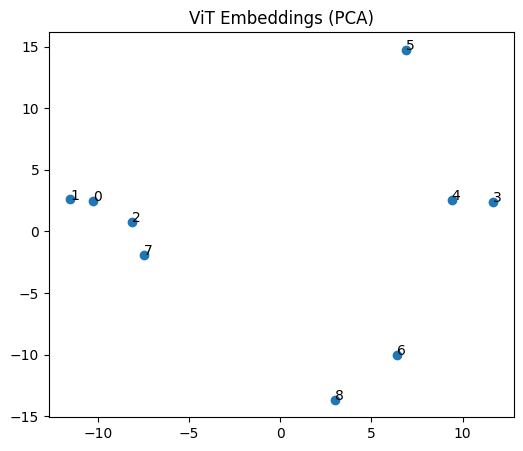

In [ ]:
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(6, 5))

plt.scatter(reduced[:, 0], reduced[:, 1])

for i, txt in enumerate(range(len(urls))):
    plt.annotate(txt, (reduced[i, 0], reduced[i, 1]))

plt.title("ViT Embeddings (PCA)")
plt.show()

t-SNE (better visualization)

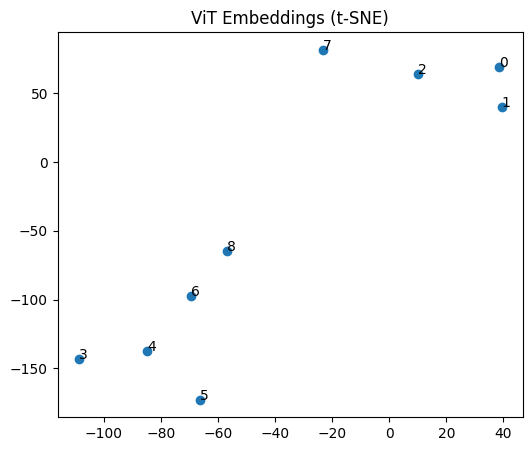

In [ ]:
tsne = TSNE(n_components=2, perplexity=2, random_state=42)
reduced_tsne = tsne.fit_transform(embeddings)

plt.figure(figsize=(6, 5))

plt.scatter(reduced_tsne[:, 0], reduced_tsne[:, 1])

for i in range(len(urls)):
    plt.annotate(i, (reduced_tsne[i, 0], reduced_tsne[i, 1]))

plt.title("ViT Embeddings (t-SNE)")
plt.show()

Add real clustering (KMeans)

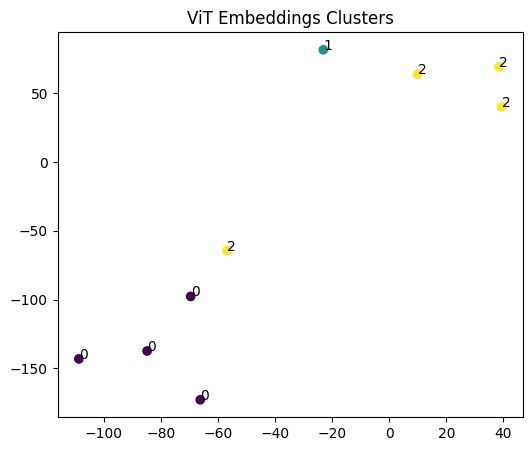

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(embeddings)

plt.figure(figsize=(6, 5))

plt.scatter(reduced_tsne[:, 0], reduced_tsne[:, 1], c=labels)

for i in range(len(urls)):
    plt.annotate(labels[i], (reduced_tsne[i, 0], reduced_tsne[i, 1]))

plt.title("ViT Embeddings Clusters")
plt.show()